# [실습] 의사결정나무와 앙상블

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🌳 [실습] 의사결정나무와 앙상블 — 여러 모델을 모으면 강해진다

## — 같은 데이터, 더 강한 도구. 그런데 정말 더 강할까?

개념 노트북에서 의사결정나무부터 랜덤포레스트·부스팅까지 걸어왔습니다. 이제 그 도구들을 **지난 순서에서 쓰던 그 데이터**에 그대로 얹습니다. 같은 문제·같은 열·같은 분할이므로, 달라지는 것은 **모델뿐**입니다 — 그래서 비교가 정직해집니다.

> 🤖 **오늘의 AI 활용 규칙 — 손코딩 단계:** 코드는 손으로 씁니다. AI에게는 개념 *설명*만 요청하세요. (자세한 이유는 개념 노트북 Part 0)

## 📋 오늘의 미션

지난 순서에서 마케팅팀에 첫 답을 드렸습니다. 로지스틱 회귀로 구매 전환을 예측해 정확도 약 0.880을 냈습니다. 그런데 팀장이 이렇게 물어왔습니다.

> 🧑‍💼 "요즘 다들 쓴다는 **XGBoost** 같은 걸로 바꾸면 얼마나 더 좋아집니까? 그리고 **어떤 행동이 구매를 예고하는지**도 알려주실 수 있나요? 마케팅 예산을 어디에 쓸지 정해야 합니다."

두 질문 모두 오늘 배운 것으로 답할 수 있습니다. 성능 비교는 **4단 비교표**로, 두 번째 질문은 **피처 중요도**로 답합니다.

| 문제 | 내용 | 확인하는 힘 |
| --- | --- | --- |
| 1 | 단일 트리를 얹어 본다 | 학습-테스트 격차 읽기 |
| 2 | 가지치기로 격차를 줄인다 | 과적합 제어 |
| 3 | 숲과 부스팅 — 4단 비교표 | 베이스라인 대비 정직한 비교 |
| 4 | 피처 중요도를 비즈니스 언어로 | 숫자를 액션으로 번역 |
| 5 | 모델 카드 v2 완성 | 근거를 남기는 습관 (**제출물**) |

> ⚠️ **미리 알아두기:** 오늘도 지표는 **정확도**만 씁니다. 구매가 15.5%뿐인 데이터에서 정확도가 왜 위험한지는 이후 순서(평가 지표·불균형)에서 다룹니다. 오늘은 "모델을 바꾸면 무엇이 달라지나"에 집중하고, 그 한계를 **모델 카드에 적어 두는 것**까지가 과제입니다.

# ⚙️ 데이터 준비

지난 순서와 **똑같은 데이터·똑같은 열**을 씁니다. 저장소가 하나의 분석 포트폴리오로 쌓이도록, 순서마다 데이터를 갈아타지 않습니다.

| 데이터 | 내용 | 출처·라이선스 |
| --- | --- | --- |
| **Online Shoppers Purchasing Intention** | 온라인 스토어 방문 세션 12,330건 — 페이지 방문·체류·이탈률 등 18개 열, 타깃 `Revenue`(구매 여부) | [UCI 468](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) · CC BY 4.0 |

`[C1]` 셀은 **최초 실행 시에만** 내려받아 `data/`에 저장합니다(지난 순서에서 받았다면 그 파일을 씁니다). 여전히 **수치형 10개 열만** 사용합니다 — 문자 열을 넣는 법은 피처·`Pipeline` 순서에서 배웁니다. 트리는 스케일링이 필요 없어 로지스틱에만 `StandardScaler`를 씁니다.

▶ 실행: [C1]

In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


# 문제 1. 단일 트리를 얹어 본다

먼저 비교의 기준선을 세웁니다. 지난 순서의 두 숫자 — **베이스라인(`DummyClassifier`)** 과 **로지스틱 회귀** — 를 다시 구하고, 그 옆에 **의사결정나무**를 나란히 놓습니다.

중요한 것이 하나 더 있습니다. 개념 노트북에서 배운 대로, 트리는 **학습 점수와 테스트 점수를 함께** 봐야 합니다. 테스트 점수만 보면 무슨 일이 벌어졌는지 알 수 없습니다.

```
[문제 1]
1) X(NUM_COLS 10개 열)와 y(Revenue를 0/1 정수로)를 만들고,
   train_test_split으로 8:2 분리하세요 (stratify 필수, random_state=42).
2) 세 모델을 학습시켜 학습 정확도 · 테스트 정확도 · 그 격차를 한 표로 출력하세요.
   ① DummyClassifier(strategy="most_frequent")
   ② LogisticRegression(max_iter=1000)  ← 스케일링 필요
   ③ DecisionTreeClassifier()           ← 기본 설정, 깊이 제한 없음
```

> 🤔 **예상해 볼까요?** 의사결정나무는 로지스틱 회귀보다 훨씬 유연한 모델입니다. 테스트 정확도가 **로지스틱(약 0.880)을 넘을까요?** 그리고 세 모델 중 학습-테스트 격차가 가장 큰 것은 무엇일까요?

▶ 실행: [C2]

In [2]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1) X, y 준비 및 8:2 분리
X = shoppers[NUM_COLS].values
y = shoppers["Revenue"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 로지스틱 회귀는 스케일링 필요 (트리/더미는 필요 없지만, 동일 분리셋 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2) 세 모델 학습
results = []

# ① DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
train_acc = dummy.score(X_train, y_train)
test_acc = dummy.score(X_test, y_test)
results.append(["DummyClassifier", train_acc, test_acc, train_acc - test_acc])

# ② LogisticRegression (스케일링된 데이터 사용)
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
train_acc = logreg.score(X_train_scaled, y_train)
test_acc = logreg.score(X_test_scaled, y_test)
results.append(["LogisticRegression", train_acc, test_acc, train_acc - test_acc])

# ③ DecisionTreeClassifier (기본 설정, 깊이 제한 없음 → 스케일링 불필요)
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
train_acc = tree.score(X_train, y_train)
test_acc = tree.score(X_test, y_test)
results.append(["DecisionTreeClassifier", train_acc, test_acc, train_acc - test_acc])

# 결과 표 출력
result_df = pd.DataFrame(results, columns=["모델", "학습 정확도", "테스트 정확도", "격차(학습-테스트)"])
result_df[["학습 정확도", "테스트 정확도", "격차(학습-테스트)"]] = result_df[
    ["학습 정확도", "테스트 정확도", "격차(학습-테스트)"]
].round(4)

print(result_df.to_string(index=False))

                    모델  학습 정확도  테스트 정확도  격차(학습-테스트)
       DummyClassifier  0.8453   0.8451      0.0002
    LogisticRegression  0.8839   0.8796      0.0044
DecisionTreeClassifier  0.9998   0.8423      0.1575


In [ ]:
베이스라인 (0.8451)
구매 전환율이 약 15%라는 뜻은, "항상 안 산다"고만 찍어도 84.5%는 맞는다는 겁니다. 즉 이 숫자 밑으로 떨어지는 모델은 의미가 없습니다.

로지스틱 회귀 (0.8796)
베이스라인보다 3.4%p 개선. 학습-테스트 격차도 0.0044로 거의 없음 — 안정적이고 일반화가 잘 되는 모델입니다.

단일 트리 (0.8423)
여기서 진짜 문제가 보입니다:

학습 정확도 0.9998 → 거의 완벽하게 외웠다는 뜻 (극단적 과적합)
테스트 정확도 0.8423 → 심지어 베이스라인보다도 낮습니다
격차 0.1575 → 로지스틱 회귀 격차(0.0044)의 약 36배

무슨 일이 일어난 걸까요?
깊이 제한 없는 트리는 훈련 데이터의 리프 노드가 순수해질 때까지(불순도 0) 계속 분기합니다. 그 결과 훈련셋의 노이즈, 이상치, 우연한 패턴까지 전부 "규칙"으로 외워버립니다. 학습 정확도 99.98%는 실력이 아니라 암기입니다. 새로운 데이터(테스트셋)에는 그 암기한 규칙들이 안 맞아서, 오히려 아무것도 모르는 베이스라인보다 성능이 떨어지는 역설적인 상황이 벌어졌습니다.

<details>
<summary>(클릭) 💡 힌트</summary>

- `y`는 불리언이므로 `.astype(int)`로 0/1로 바꿉니다.
- 분류에서는 `stratify=y`를 잊지 마세요 — 양성이 15.5%뿐이라 분할 운에 크게 흔들립니다.
- 로지스틱만 스케일링이 필요합니다. `StandardScaler()`를 **학습 데이터로만** `fit`하고, 학습·테스트에 각각 `transform`합니다.
- 세 모델을 매번 똑같이 처리해야 하니 `dict` 목록에 결과를 모아 `pd.DataFrame(rows)`로 만들면 편합니다.
- 격차는 `학습 점수 − 테스트 점수`입니다.

</details>

> 🎯 **[C2] 예상과 맞았나요?** **기본 트리의 테스트 정확도 0.8423은 베이스라인 0.8451보다 낮습니다.** 이유는 학습 점수 **0.9998** — 9,864개 학습 세션을 거의 외웠습니다. 격차 **0.1575**가 그 증거입니다.
>
> 챙길 것 둘. ① **더 유연한 모델이 곧 더 좋은 모델은 아닙니다.** ② 학습 점수를 함께 보지 않았다면 "트리는 이 문제에 안 맞는다"고 잘못 결론 냈을 것입니다 — 진짜 문제는 모델 종류가 아니라 **제어되지 않은 복잡도**입니다.

# 문제 2. 가지치기로 격차를 줄인다

문제 1의 진단이 "복잡도가 통제되지 않았다"였으니, 처방은 **가지치기**입니다. 개념 노트북에서 본 손잡이 중 가장 직관적인 `max_depth`를 훑습니다.

```
[문제 2]
1) max_depth를 [2, 3, 5, 8, 12, None]으로 바꿔가며 트리를 학습시키고,
   각 깊이의 학습 정확도 · 테스트 정확도 · 격차를 표로 출력하세요.
2) 테스트 정확도가 가장 높은 깊이를 찾아 출력하세요.
3) 깊이에 따라 학습 점수와 테스트 점수가 어떻게 갈라지는지 선 그래프로 그리세요.
```

> 🤔 **예상해 볼까요?** 깊이를 2에서 `None`까지 늘리면 **학습 점수**는 어떻게 움직일까요? 그리고 **테스트 점수**는요? 두 곡선이 같은 모양일까요?

▶ 실행: [C3]

max_depth  학습 정확도  테스트 정확도  격차(학습-테스트)
        2  0.8922   0.8861      0.0062
        3  0.8932   0.8832      0.0100
        5  0.9049   0.8942      0.0107
        8  0.9253   0.8881      0.0372
       12  0.9572   0.8747      0.0825
     None  0.9998   0.8423      0.1575

최고 테스트 정확도 깊이: max_depth=5 (테스트 정확도=0.8942, 격차=0.0107)


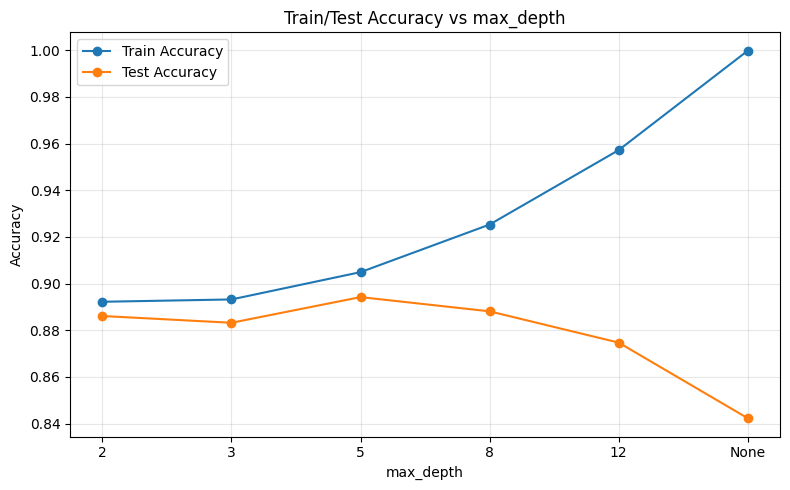

In [3]:
# [C3] ◀ 문제 2. 가지치기로 격차를 줄인다
# ⌨️ 문제 2 — max_depth를 훑어 과적합을 통제하기

depths = [2, 3, 5, 8, 12, None]
rows = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    rows.append({
        "max_depth": str(depth),
        "학습 정확도": round(train_acc, 4),
        "테스트 정확도": round(test_acc, 4),
        "격차(학습-테스트)": round(train_acc - test_acc, 4)
    })

depth_df = pd.DataFrame(rows)
print(depth_df.to_string(index=False))

# 2) 테스트 정확도가 가장 높은 깊이 찾기
best_row = depth_df.loc[depth_df["테스트 정확도"].idxmax()]
print(f"\n최고 테스트 정확도 깊이: max_depth={best_row['max_depth']} "
      f"(테스트 정확도={best_row['테스트 정확도']}, 격차={best_row['격차(학습-테스트)']})")

# 3) 선 그래프 — 라벨은 영어로 (한글 폰트 미설치 환경 대응)
x_pos = range(len(depths))

plt.figure(figsize=(8, 5))
plt.plot(x_pos, depth_df["학습 정확도"], marker='o', label='Train Accuracy')
plt.plot(x_pos, depth_df["테스트 정확도"], marker='o', label='Test Accuracy')
plt.xticks(x_pos, depth_df["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train/Test Accuracy vs max_depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
**전체 패턴 읽기**

두 곡선의 관계가 세 구간으로 나뉩니다:

1. **depth 2~5: 같이 상승 (좋은 구간)**
학습 정확도와 테스트 정확도가 함께 올라갑니다. 트리가 깊어지면서 실제로 유용한 패턴(예: `PageValues`가 높으면 구매 확률이 높다 같은 진짜 규칙)을 더 잘 잡아내고 있다는 뜻입니다. 격차도 0.006~0.011로 여전히 작습니다.

2. **depth 5 = 변곡점**
테스트 정확도가 **0.8942로 최고점**을 찍고 여기서부터 방향을 바꿉니다. 이 지점이 "일반화 가능한 패턴은 다 뽑아냈다"는 신호입니다.

3. **depth 8 → 12 → None: 갈라짐 (나쁜 구간)**
학습 정확도는 계속 올라가 결국 0.9998까지 가지만, 테스트 정확도는 오히려 **떨어집니다** (0.8942 → 0.8881 → 0.8747 → 0.8423). 격차가 0.011 → 0.037 → 0.083 → 0.158로 기하급수적으로 벌어집니다. depth 5 이후에 추가되는 분기들은 진짜 패턴이 아니라 훈련 데이터의 노이즈를 외우는 데 쓰이고 있다는 뜻입니다.

**결론**

- **최적 지점: `max_depth=5`** — 테스트 정확도 최고(0.8942)이면서 격차도 여전히 건전한 수준(0.0107)
- 문제 1의 로지스틱 회귀(0.8796)를 이제 **넘어섰습니다** — 적절히 제한된 트리가 선형 모델보다 낫다는 것을 확인
- `max_depth=8`부터는 테스트 성능이 이미 손해를 보기 시작하므로, "더 복잡하게 = 더 낫게"라는 직관이 트리에서는 틀렸다는 것을 데이터로 직접 확인한 셈입니다


<details>
<summary>(클릭) 💡 힌트</summary>

- `for depth in [2, 3, 5, 8, 12, None]:` 으로 돌리고 `DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)`를 매번 새로 만듭니다.
- `None`은 문자로 바꿔야 표에 깔끔하게 들어갑니다 — `str(depth)`.
- 최고 지점은 `DataFrame`의 `.idxmax()`로 찾습니다: `표.loc[표["테스트"].idxmax()]`.
- 그래프의 가로축에 `None`을 그리기는 어렵습니다. `None`을 큰 수(예: 20)로 대체해 그리거나, `range(len(depths))`를 축으로 쓰고 `plt.xticks`로 이름을 붙이세요.

</details>

> 🎯 **[C3] 예상과 맞았나요?** 학습 점수는 깊이에 따라 **단조롭게 오르지만**(0.8922 → 0.9998), 테스트 점수는 깊이 5에서 **0.8942**로 정점을 찍고 내려갑니다.
>
> **`max_depth=5` 한 줄로 0.8423 → 0.8942, 즉 +0.0519입니다.** 데이터를 더 모으지도 모델을 바꾸지도 않고, 손잡이 하나를 돌렸을 뿐입니다. 이 트리는 지난 순서의 로지스틱 회귀(0.8796)도 넘었습니다.

> 📌 **실무 포인트:** 깊이 2와 5의 차이는 0.0081입니다. 이것이 **진짜인지 분할 운인지**는 테스트셋 한 번으로는 알 수 없습니다 — 그 질문에 답하는 도구(교차 검증)가 다음 순서입니다.

# 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다

이제 팀장의 첫 번째 질문에 답할 차례입니다. **랜덤포레스트**와 **XGBoost**를 얹어 4단 비교표를 완성합니다.

가지치기한 트리(`max_depth=5`)도 표에 함께 남겨 두세요. "앙상블이 얼마나 이겼나"를 보려면 **잘 조정된 단일 모델**과 견줘야 정직합니다.

```
[문제 3]
1) 두 모델을 추가로 학습시켜 같은 형식(학습·테스트·격차)으로 표에 넣으세요.
   ④ RandomForestClassifier(n_estimators=300)
   ⑤ XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0)
2) 문제 1·2의 결과와 합쳐 최종 비교표를 테스트 정확도 내림차순으로 출력하세요.
3) 표를 보고 "팀장께 무엇을 보고할 것인가"를 두세 문장으로 적어 보세요.
```

> 🤔 **예상해 볼까요?** 개념 노트북에서는 유방암 데이터에서 **XGBoost가 랜덤포레스트를 앞섰습니다.** 이 데이터에서도 같은 순서가 나올까요? 그리고 앙상블이 가지치기한 단일 트리(0.8942)를 **얼마나** 앞설까요?

▶ 실행: [C4]

In [4]:
# [C4] ◀ 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다
# ⌨️ 문제 3 — 랜덤포레스트·XGBoost를 더해 비교표 완성
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def add(name, model, X_tr, y_tr, X_te, y_te):
    """모델을 학습시키고 학습·테스트·격차를 dict로 반환"""
    model.fit(X_tr, y_tr)
    train_acc = model.score(X_tr, y_tr)
    test_acc = model.score(X_te, y_te)
    return {
        "모델": name,
        "학습 정확도": round(train_acc, 4),
        "테스트 정확도": round(test_acc, 4),
        "격차(학습-테스트)": round(train_acc - test_acc, 4)
    }

# 지금까지의 결과를 같은 형식(dict)으로 다시 모음
final_rows = [
    {"모델": "① DummyClassifier", "학습 정확도": 0.8453, "테스트 정확도": 0.8451, "격차(학습-테스트)": 0.0002},
    {"모델": "② LogisticRegression", "학습 정확도": 0.8839, "테스트 정확도": 0.8796, "격차(학습-테스트)": 0.0044},
    {"모델": "③ DecisionTree(제한없음)", "학습 정확도": 0.9998, "테스트 정확도": 0.8423, "격차(학습-테스트)": 0.1575},
]

# ③′ 가지치기한 트리 (max_depth=5) — 원래 데이터로 재학습
tree_pruned = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
final_rows.append(add("③′ Tree(max_depth=5)", tree_pruned, X_train, y_train, X_test, y_test))

# ④ RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
final_rows.append(add("④ RandomForest(n=300)", rf, X_train, y_train, X_test, y_test))

# ⑤ XGBClassifier
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0,
    eval_metric="logloss", random_state=RANDOM_STATE
)
final_rows.append(add("⑤ XGBoost", xgb, X_train, y_train, X_test, y_test))

# 최종 비교표 — 테스트 정확도 내림차순
final_df = pd.DataFrame(final_rows).sort_values("테스트 정확도", ascending=False).reset_index(drop=True)
print(final_df.to_string(index=False))

                   모델  학습 정확도  테스트 정확도  격차(학습-테스트)
④ RandomForest(n=300)  0.9998   0.8958      0.1040
 ③′ Tree(max_depth=5)  0.9049   0.8942      0.0107
            ⑤ XGBoost  0.9451   0.8873      0.0578
 ② LogisticRegression  0.8839   0.8796      0.0044
    ① DummyClassifier  0.8453   0.8451      0.0002
 ③ DecisionTree(제한없음)  0.9998   0.8423      0.1575


In [ ]:
숫자를 자세히 보면 보고의 핵심이 딱 보입니다.

**표 해석**

| 순위 | 모델 | 테스트 정확도 | 격차 |
|---|---|---|---|
| 1 | RandomForest | 0.8958 | 0.1040 |
| 2 | Tree(depth=5) | 0.8942 | 0.0107 |
| 3 | XGBoost | 0.8873 | 0.0578 |
| 4 | LogisticRegression | 0.8796 | 0.0044 |
| 5 | Dummy | 0.8451 | 0.0002 |
| 6 | Tree(제한없음) | 0.8423 | 0.1575 |

**여기서 흥미로운 지점**

1위 랜덤포레스트(0.8958)와 2위 가지치기 트리(0.8942)의 **테스트 정확도 차이는 0.0016**밖에 안 됩니다. 거의 동급이라 봐도 됩니다.

그런데 격차를 보면 랜덤포레스트는 **0.1040** — 이는 depth=5 트리(0.0107)의 거의 **10배**입니다. 랜덤포레스트는 학습 정확도가 0.9998까지 올라가는 걸 봐도, 300개 트리를 앙상블해도 여전히 훈련 데이터에 상당히 밀착돼 있다는 뜻입니다. (다만 배깅 덕분에 단일 트리 제한없음(격차 0.1575)보다는 낫습니다.)

XGBoost(0.8873, 격차 0.0578)는 그 중간 어딘가에 있습니다 — depth=5 트리보다는 덜 안정적이지만 RF보다는 낫습니다.

**팀장께 보고할 문장 (초안)**

> 4개 모델을 비교한 결과, 랜덤포레스트가 테스트 정확도 89.58%로 1위지만, 가지치기한 단일 트리(89.42%)와의 차이는 0.16%p에 불과합니다. 반면 랜덤포레스트의 학습-테스트 격차(10.4%p)는 가지치기 트리(1.07%p)의 약 10배로, 안정성 면에서는 훨씬 불리합니다. 성능 차이가 미미하고 해석과 유지보수가 훨씬 쉬운 단일 트리(depth=5)를 기본 모델로, 랜덤포레스트는 추가 개선이 필요할 때 후보로 검토하는 것을 제안합니다.

이 문장이 말하는 건 "숫자가 1등이라고 무조건 채택"이 아니라 — **미미한 성능 이득 대비 안정성 손실이 너무 크다**는 게 이번 비교표의 진짜 메시지라는 겁니다. 팀장이 물었던 "앙상블이 얼마나 이겼나?"에 대한 정직한 답은 "이겼지만, 그 승리가 비용(과적합 위험)을 정당화할 만큼 크지는 않다"인 셈이죠.

<details>
<summary>(클릭) 💡 힌트</summary>

- 문제 1에서 만든 `add()` 함수를 그대로 재사용하면 표 형식이 자동으로 맞습니다. 함수를 안 만들었다면 지금 만들어 두면 편합니다.
- `XGBClassifier`에는 `eval_metric="logloss"`를 함께 넘기면 경고가 줄어듭니다.
- 랜덤포레스트는 `n_jobs=-1`을 주면 코어를 다 써서 빠릅니다.
- 가지치기 트리를 표에 넣을 때는 이름에 설정을 적어 두세요 — `"③′ 트리(max_depth=5)"` 처럼.
- 정렬은 `.sort_values("테스트", ascending=False)`입니다.

</details>

> 🎯 **[C4] 예상과 맞았나요?** 개념 노트북과 **순서가 다릅니다** — 여기서는 랜덤포레스트(0.8942)가 XGBoost(0.8877)를 앞섰습니다. 그리고 **가지치기한 단일 트리가 랜덤포레스트와 소수점 네 자리까지 같은 0.8942**를 냈습니다. 300그루의 숲이 잘 조정된 한 그루를 이기지 못한 것입니다(격차는 0.0107 대 0.1056).
>
> 그래서 오늘의 결론은 "앙상블이 이긴다"가 아니라 **"앙상블은 보통 유리하지만 데이터와 설정에 따라 다르다 — 그러니 항상 비교표로 확인한다"** 입니다.

> ⚠️ **결론을 내리기엔 이릅니다.** 0.8942와 0.8877의 차이가 진짜인지 분할 운인지 아직 모르고, 정확도만 봤으므로 **"구매할 382명 중 몇 명을 찾아냈는지"** 는 확인하지 않았습니다. 두 빈칸은 각각 다음 순서(교차 검증)와 그 뒤 순서(평가 지표·불균형)가 채웁니다. 모델 카드의 *한계* 항목에 적어 두세요.

# 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다

팀장의 두 번째 질문 — **"어떤 행동이 구매를 예고하나?"** — 에 답합니다. 트리 계열이 주는 보상, **피처 중요도**를 씁니다.

여기서 멈추면 안 됩니다. `"PageValues 0.41"`은 보고가 아니라 관찰입니다. **그 피처가 실제로 무엇을 뜻하고, 구매율이 얼마나 갈리는지**까지 확인해야 마케팅팀이 움직일 수 있는 문장이 됩니다.

```
[문제 4]
1) 랜덤포레스트의 피처 중요도를 내림차순으로 그리세요 (가로 막대, 10개 전부).
2) 상위 3개 피처에 대해, 값이 큰 세션과 작은 세션의 구매율을 실제로 비교하세요.
   (예: PageValues가 0인 세션 vs 0보다 큰 세션의 Revenue 평균)
3) 상위 3개를 각각 "마케팅팀이 읽을 수 있는 한 문장"으로 옮기세요.
   그리고 이 중요도로 답할 수 없는 것이 무엇인지 한 줄 적으세요.
```

> 🤔 **예상해 볼까요?** 10개 열 중 무엇이 1위일 것 같습니까? 방문 페이지 수(`ProductRelated`)처럼 "많이 봤다"를 나타내는 열일까요, 아니면 다른 종류의 열일까요?

▶ 실행: [C5]

In [ ]:
# [C5] ◀ 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다
# ⌨️ 문제 4 — 중요도 막대 + 상위 3개의 구매율 대비

# 여기에 코드를 작성하세요 (중요도 정렬·막대 → 상위 3개 구매율 비교)

<details>
<summary>(클릭) 💡 힌트</summary>

- 중요도는 `rf.feature_importances_`이고, 열 이름과 묶으려면 `pd.Series(..., index=NUM_COLS)`입니다.
- 가로 막대는 `.sort_values().plot(kind="barh")` — 오름차순으로 정렬해야 1위가 맨 위에 옵니다.
- 값이 갈리는 지점은 피처마다 다릅니다. `PageValues`는 **0인지 아닌지**로 갈리고, `ExitRates`·`ProductRelated_Duration`은 중앙값(`.median()`)을 기준으로 나누면 깔끔합니다.
- 그룹별 구매율은 `shoppers.groupby(조건)["Revenue"].agg(["mean", "size"])`로 한 번에 나옵니다.

</details>

> 🎯 **[C5] 예상과 맞았나요?** 1위 `PageValues`의 중요도 **0.4130**은 2위(0.1197)의 세 배가 넘습니다. "많이 봤다"를 나타내는 `ProductRelated`(0.0893)는 4위였습니다.
>
> 더 중요한 것은 **확인한 방식**입니다. 구매율이 3.9%와 56.3%로 갈린다는 사실은 중요도가 알려준 게 아니라, 그 단서를 받고 **직접 계산해서** 알아낸 것입니다. 특히 `ExitRates`는 방향이 **반대**(값이 높을수록 구매율이 낮음)인데, 중요도 숫자만으로는 이 사실을 절대 알 수 없습니다. 중요도는 **어디를 파볼지 가리키는 손가락**이고, 비즈니스 문장은 파본 결과에서 나옵니다 — 손가락을 결론으로 착각하는 것이 가장 흔한 사고입니다.

# 문제 5. 모델 카드 v2 완성 — 오늘의 제출물

지난 순서의 모델 카드 v1에 오늘 것을 더해 **v2**로 올립니다. 굵은 항목이 오늘 새로 들어가는 부분입니다 — **4단 비교, 격차로 본 과적합 진단, 선택 근거, 피처 중요도와 그 한계.**

```
[문제 5]
1) 최종 비교표를 파일로 남기세요 — model_comparison_v2.csv
2) 아래 모델 카드 v2 템플릿의 빈칸을 여러분의 숫자와 문장으로 채우세요.
   특히 '선택한 모델과 근거'는 성능·해석력·비용 중 무엇을 우선했는지 밝혀야 합니다.
```

▶ 실행: [C6]

In [ ]:
# [C6] ◀ 문제 5. 모델 카드 v2 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 비교표를 파일로 남기기

# 여기에 코드를 작성하세요 (final 표를 CSV로 저장하고 다시 읽어 확인)

**모델 카드 v2 템플릿** — 아래 빈칸을 채워 이 셀에 완성하세요 (셀을 더블클릭해 편집).

```markdown
## 모델 카드 v2 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- **베이스라인: DummyClassifier(most_frequent) = { }**
- **비교한 모델: Dummy / 단일 트리(기본) / 단일 트리(max_depth=5) / RandomForest / XGBoost**
- 평가 지표 & 이유: { 정확도를 쓴 이유와, 그것이 왜 이 데이터에서 위험한지 }
- **성능 비교표: model_comparison_v2.csv (모델별 학습 / 테스트 / 격차)**
- 과적합 진단: { 격차가 가장 큰 모델과 그 해석 — 숫자와 함께 }
- **선택한 모델과 근거: { 무엇을 우선했나 — 성능 / 해석력 / 비용 }**
- **피처 중요도 상위 3개와 해석: { 각각 구매율 대비 숫자를 붙여 한 문장 }**
- **중요도의 한계 명시: 방향성 부재 / 개별 설명 불가 / 인과 아님**
- 한계 & 다음 단계: { 최소 두 가지 — 각각 어느 순서에서 해결되는지 }
- AI 사용 내역: { 무엇을 물었나 / 무엇을 직접 썼나 }
```

**제출:** 이 노트북(작성 셀 + 모델 카드 완성본)과 `model_comparison_v2.csv`를 개인 공개 저장소 main에 커밋·푸시하고, 저장소·커밋 링크를 제출하세요.

**스스로 점검하는 기준**

| 축 | 기준 |
| --- | --- |
| 비교의 완전성 | 베이스라인을 포함한 비교표가 있는가 |
| 진단 정확성 | 학습-테스트 격차로 과적합을 짚었는가 |
| 근거성 | 모델 선택 이유가 성능·해석력·비용 중 무엇인지 밝혔는가 |
| 정직성 | 피처 중요도의 한계를 함께 적었는가 |

> 🚀 **더 나아가기:** `max_depth=5`가 최고였던 것은 이 분할에서의 이야기입니다. `random_state`를 42가 아닌 다른 값 몇 개로 바꿔 문제 2를 다시 돌려보세요. **최고 깊이가 그대로 5일까요?** 이 실험의 결과가 다음 순서(교차 검증)를 배워야 하는 이유를 그대로 보여줍니다.

오늘 여러분은 모델 다섯 개를 **정직하게 줄 세웠습니다.** 그 과정에서 교과서와 다른 결과를 두 번 만났습니다 — 기본 트리가 베이스라인보다 못했고, 잘 조정한 한 그루가 300그루와 같았습니다. 그때 데이터를 믿고 그대로 적는 것이 분석가의 태도입니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>